In [3]:
import pandas as pd
import math
import numpy as np
import datetime as dtm
from scipy.optimize import curve_fit
import os
import networkx as nx
import h3
import powerlaw
from scipy.stats import kstest
import folium
from shapely.geometry import Polygon
import matplotlib.pyplot as plt
import json
from branca.colormap import linear
from textwrap import fill
from turtle import color, fillcolor

np.set_printoptions(suppress=True)

坐标转换

In [4]:
x_pi = 3.14159265358979324 * 3000.0 / 180.0
pi = 3.1415926535897932384626
a = 6378245.0
ee = 0.00669342162296594323

def _transformlat(lng, lat):

    ret = -100.0 + 2.0 * lng + 3.0 * lat + 0.2 * lat * lat + 0.1 * lng * lat + 0.2 * math.sqrt(math.fabs(lng))
    ret += (20.0 * math.sin(6.0 * lng * pi) + 20.0 * math.sin(2.0 * lng * pi)) * 2.0 / 3.0
    ret += (20.0 * math.sin(lat * pi) + 40.0 * math.sin(lat / 3.0 * pi)) * 2.0 / 3.0
    ret += (160.0 * math.sin(lat / 12.0 * pi) + 320 * math.sin(lat * pi / 30.0)) * 2.0 / 3.0

    return ret

def _transformlng(lng, lat):

    ret = 300.0 + lng + 2.0 * lat + 0.1 * lng * lng + 0.1 * lng * lat + 0.1 * math.sqrt(math.fabs(lng))
    ret += (20.0 * math.sin(6.0 * lng * pi) + 20.0 * math.sin(2.0 * lng * pi)) * 2.0 / 3.0
    ret += (20.0 * math.sin(lng * pi) + 40.0 * math.sin(lng / 3.0 * pi)) * 2.0 / 3.0
    ret += (150.0 * math.sin(lng / 12.0 * pi) + 300.0 * math.sin(lng / 30.0 * pi)) * 2.0 / 3.0

    return ret

def out_of_china(lng, lat):

    """
    判断是否在国内，不在国内不做偏移
    :param lng:
    :param lat:
    :return:
    """

    return not (lng > 73.66 and lng < 135.05 and lat > 3.86 and lat < 53.55)

def bd09_to_gcj02(bd_lon, bd_lat):
    """
    百度坐标系(BD-09)转火星坐标系(gcJ-02)
    :param bd_lat:百度坐标纬度
    :param bd_lon:百度坐标经度
    :return:转换后的坐标列表形式
    """
    x = bd_lon - 0.0065
    y = bd_lat - 0.006
    z = math.sqrt(x * x + y * y) - 0.00002 * math.sin(y * x_pi)
    theta = math.atan2(y, x) - 0.000003 * math.cos(x * x_pi)
    gg_lng = z * math.cos(theta)
    gg_lat = z * math.sin(theta)
    return gg_lng, gg_lat

def gcj02_to_wgs84(lng, lat):
    """
    gcJ02(火星坐标系)转GPS84
    :param lng:火星坐标系的经度
    :param lat:火星坐标系纬度
    :return:
    """
    if out_of_china(lng, lat):

        return [lng, lat]
    dlat = _transformlat(lng - 105.0, lat - 35.0)
    dlng = _transformlng(lng - 105.0, lat - 35.0)
    radlat = lat / 180.0 * pi
    magic = math.sin(radlat)
    magic = 1 - ee * magic * magic
    sqrtmagic = math.sqrt(magic)
    dlat = (dlat * 180.0) / ((a * (1 - ee)) / (magic * sqrtmagic) * pi)
    dlng = (dlng * 180.0) / (a / sqrtmagic * math.cos(radlat) * pi)
    mglat = lat + dlat
    mglng = lng + dlng

    return lng * 2 - mglng, lat * 2 - mglat

def wgs84_to_gcj02(lng, lat):
    """
    WGS84转GCJ02(火星坐标系)
    :param lng:WGS84坐标系的经度
    :param lat:WGS84坐标系的纬度
    :return:
    """
    if out_of_china(lng, lat):  # 判断是否在国内
        return [lng, lat]
    dlat = _transformlat(lng - 105.0, lat - 35.0)
    dlng = _transformlng(lng - 105.0, lat - 35.0)
    radlat = lat / 180.0 * pi
    magic = math.sin(radlat)
    magic = 1 - ee * magic * magic
    sqrtmagic = math.sqrt(magic)
    dlat = (dlat * 180.0) / ((a * (1 - ee)) / (magic * sqrtmagic) * pi)
    dlng = (dlng * 180.0) / (a / sqrtmagic * math.cos(radlat) * pi)
    mglat = lat + dlat
    mglng = lng + dlng
    return mglng, mglat

def bd09_to_wgs84(bd_lon, bd_lat):

    gcj_lng, gcj_lat = bd09_to_gcj02(bd_lon, bd_lat)
    wgs_lng, wgs_lat = gcj02_to_wgs84(gcj_lng, gcj_lat)

    return wgs_lng, wgs_lat


线路、站点信息整理

In [5]:
def station_line_combine(line,line_station,demand):
    line = line[['subline_oneway_id','direction','subline_id','oneway_name']]
    line_station = line_station[['subline_oneway_id','station_id','sngserial_id','dualserial_id']]
    line_station = pd.merge(line_station,line,how='left',on='subline_oneway_id')
    
    demand = demand[['oneway_id','station_id','ridership']].rename(columns={'oneway_id':'subline_oneway_id'})
    demand = demand.groupby(['subline_oneway_id','station_id'],as_index=False).agg(np.sum)
    line_station = pd.merge(line_station,demand,how='left',on=['subline_oneway_id','station_id']).fillna(0)
    line_station = line_station[line_station['subline_id']!=0]

    return line_station.rename(columns={'ridership':'boarding'}).reset_index(drop=True)

In [6]:
def get_distance_hav(lat0,lng0,lat1,lng1):
    EARTH_RADIUS = 6378.245
    def hav(theta):
        s = math.sin(theta/2)
        return s*s
    
    lat0 = math.radians(lat0)
    lng0 = math.radians(lng0)
    lat1 = math.radians(lat1)
    lng1 = math.radians(lng1)
    dlng = math.fabs(lng0-lng1)
    dlat = math.fabs(lat0-lat1)
    h = hav(dlat)+math.cos(lat0)*math.cos(lat1)*hav(dlng)
    dis = 2*EARTH_RADIUS*math.asin(math.sqrt(h))
    return dis*1000

计算站点吸引力概率

In [7]:
def add_weight(dir_1,dir_2,poi_sum,alpha):

    dir_2 = dir_2[['station_id','station_id','boarding']]
    dir_2.columns = ['station_id','reversed_station','reversed_boarding']
    df = pd.merge(dir_1,dir_2,how='left',on='station_id').sort_values('sngserial_id').reset_index(drop=True)
    df['reversed_boarding'] = df['reversed_boarding'].fillna(df['reversed_boarding'].interpolate())
    if df['reversed_boarding'].sum() > 0:
        df['weight_boarding'] = df.apply(lambda x: x['reversed_boarding']/df['reversed_boarding'].sum(),axis=1)
    else:
        df['weight_boarding'] = 0
    
    df = pd.merge(df,poi_sum,how='left',on='station_id')
    if df['poi_sum'].sum() > 0:
        df['weight_poi'] = df.apply(lambda x: x['poi_sum']/df['poi_sum'].sum(),axis=1)
    else:
        df['weight_poi'] = 0
    
    df['weight_all'] = df.apply(lambda x: alpha*x['weight_boarding']+(1-alpha)*x['weight_poi'],axis=1)
    if df['weight_all'].sum() > 0:
        df['weight'] = df.apply(lambda x: x['weight_all']/df['weight_all'].sum(),axis=1)
    else:
        df['weight_all'] = 0
    return df


计算乘车距离概率

In [8]:
def take_station(data,lam):
    n = len(data)
    p = np.zeros((n,n))
    for i in range(n):
        for j in range(n):
            if i<j:
                l = np.min([lam,n-i])
                k = j-i
                p[i,j] = math.pow(l,k)*np.exp(-l)/np.math.factorial(k)
    s = p.sum(axis=1)
    for o in range(n):
        for t in range(n):
            if o<t:
                if s[o] == 0:
                    p[o,t] = 0
                else:
                    p[o,t] = p[o,t]/s[o]
    p[np.isnan(p)] = 0
    return p
                

计算下车概率

In [9]:
def prob(dir_weight,array_k):
    weight = dir_weight['weight'].values
    n = len(dir_weight)
    probility = np.zeros((n,n))
    if len(dir_weight)==len(array_k):
        for a in range(n):
            for b in range(n):
                if a<b:
                    probility[a,b] = array_k[a,b]*weight[a]
        s = probility.sum(axis=1)
        for a in range(n):
            for b in range(n):
                if a<b:
                    if s[a]!=0:
                        probility[a,b] = probility[a,b]/s[a]
                    else:
                        probility[a,b] = 0
    probility[np.isnan(probility)] = 0
    return probility


计算下车人数

In [10]:
def count_od(dataframe,pro):
    od = pd.DataFrame()
    if not dataframe.empty:
        for n in dataframe.index:
            boarding_demand = dataframe.loc[n,'boarding']
            for m in dataframe.index[n+1:]:
                alighting_pro = pro[n,m]
                od_l = pd.DataFrame({
                    "subline_id": [int(dataframe.loc[n,'subline_id'])],
                    "direction": [int(dataframe.loc[n,'direction'])],
                    "oneway_name": [dataframe.loc[n,'oneway_name']],
                    "subline_oneway_id": [dataframe.loc[n,'subline_oneway_id']],
                    "boarding_station_id": [dataframe.loc[n,'station_id']],
                    "boarding_sngserial_id": [dataframe.loc[n,'sngserial_id']],
                    "boarding_station_id": [dataframe.loc[n,'station_id']],
                    "alighting_station_id": [dataframe.loc[m,'station_id']],
                    "alighting_sngserial_id": [dataframe.loc[m,'sngserial_id']],
                    "alighting_station_id": [dataframe.loc[m,'station_id']],
                    "boarding_number": [boarding_demand],
                    "demand": [boarding_demand*alighting_pro]
                })
                od = pd.concat([od,od_l])
    return od.reset_index(drop=True)
            

对向站点识别

In [11]:
def reversed_station(subline_id,line_station,poi,alpha=0.5):
    poi_sum = pd.DataFrame({
        'station_id':poi.station_id,
        'poi_sum':poi.drop(['station_id'],axis=1).sum(axis=1)
        })
    subline_station = line_station[line_station['subline_id']==subline_id]
    if subline_station['boarding'].sum() > 0:
        up_oneway = subline_station[subline_station['direction']==2]   
        down_oneway = subline_station[subline_station['direction']==3]
        if not up_oneway.empty:
            up = add_weight(up_oneway,down_oneway,poi_sum,alpha)
            up_k = take_station(data=up,lam=int(len(up)/3))
            up_p = prob(up,up_k)
        else:
            up = pd.DataFrame()
            up_p = np.array([])
        if not down_oneway.empty:
            down = add_weight(down_oneway,up_oneway,poi_sum,alpha)
            down_k = take_station(data=down,lam=int(len(down)/2))
            down_p = prob(down,down_k)
        else:
            down = pd.DataFrame()
            down_p = np.array([])
        return up,down,up_p,down_p
    else:
        return pd.DataFrame(),pd.DataFrame(),np.array([]),np.array([])


读取数据

In [12]:
work_path = os.path.abspath(os.getcwd()+os.path.sep+"..")
data_path = os.path.join(work_path,'Raw_data','Lianyungang')

df_line = pd.read_csv(os.path.join(data_path,'subline_oneway.csv')).rename(columns={'id':'subline_oneway_id'})
df_poi = pd.read_csv(os.path.join(data_path,'oneway_station_poi.csv')).rename(columns={'Unnamed: 0':'station_id'})
df_line_station = pd.read_csv(os.path.join(data_path,'subline_oneway_station.csv'))
df_station = pd.read_csv(os.path.join(data_path,'station.csv')).rename(columns={'id':'station_id'})

输出

In [13]:
def final(target_day):
    dayname = dtm.datetime.strftime(dtm.datetime.strptime(target_day,'%Y%m%d'),'%Y-%m-%d')
    df_demand = pd.read_csv(os.path.join(data_path,'station_%s.csv' % dayname))

    oneway_station = station_line_combine(df_line,df_line_station,df_demand)
    line_name = oneway_station['subline_id'].value_counts().index

    od_frame = pd.DataFrame()
    for subline_code in line_name:
        up,down,up_p,down_p = reversed_station(subline_code,oneway_station,df_poi,alpha=0.5)
        if not up.empty:
            od_frame = pd.concat([od_frame,count_od(up,up_p)])
        if not down.empty:
            od_frame = pd.concat([od_frame,count_od(down,down_p)])
    od_frame = od_frame.reset_index(drop=True)
    station_id_od = od_frame.groupby(['boarding_station_id','alighting_station_id'],as_index=False).agg({'demand':'sum'})
    station_id_od['demand'] = station_id_od['demand'].apply(lambda x: round(x))
    station_id_od = station_id_od[station_id_od['demand']>0].reset_index(drop=True)
    return station_id_od


站点（node）

In [14]:
df_station = df_station[df_station['station_id'].isin(df_line_station['station_id'])]
df_station = df_station[['station_id','longitude','latitude']]
df_station = df_station[(df_station['latitude']<35) & (df_station['latitude']>=34.3)]
df_station = df_station[(df_station['longitude']<119.7) & (df_station['longitude']>=118.7)].reset_index(drop=True)
df_station['gcj_lng'] = df_station.apply(lambda x: bd09_to_gcj02(x['longitude'],x['latitude'])[0], axis=1)
df_station['gcj_lat'] = df_station.apply(lambda x: bd09_to_gcj02(x['longitude'],x['latitude'])[1], axis=1)
df_station['wgs_lng'] = df_station.apply(lambda x: bd09_to_wgs84(x['longitude'],x['latitude'])[0], axis=1)
df_station['wgs_lat'] = df_station.apply(lambda x: bd09_to_wgs84(x['longitude'],x['latitude'])[1], axis=1)


In [15]:
dis_id = np.zeros((len(df_station),len(df_station)))
for i in range(len(df_station)):
    for j in range(len(df_station)):
        lat0 = df_station.loc[i,'wgs_lat']
        lng0 = df_station.loc[i,'wgs_lng']
        lat1 = df_station.loc[j,'wgs_lat']
        lng1 = df_station.loc[j,'wgs_lng']
        dis_id[i,j] = get_distance_hav(lat0,lng0,lat1,lng1)
np.savetxt(os.path.join(work_path,'Results\Lianyungang','station_distance.csv'),dis_id,delimiter=',')

In [14]:
res = 9 #H3分辨率

station_data = df_station.reset_index(drop=True)
station_data['h3_address'] = station_data.apply(lambda x: h3.geo_to_h3(lat=x['wgs_lat'], lng=x['wgs_lng'], resolution=res), axis=1)
station_data['h3_centre'] = station_data.apply(lambda x: h3.h3_to_geo(h=x['h3_address']), axis=1)

df_node = station_data[['h3_address','h3_centre']].drop_duplicates(keep='first').reset_index(drop=True)
node_list = df_node.h3_address.to_list()
pos_list = []
for p in df_node.index:
    indi_pos = {df_node.h3_address[p]:df_node.h3_centre[p]}
    pos_list.append(indi_pos)

In [15]:
def change_coord(tuple_old):
    list_new = []
    for p in tuple_old:
        lng = p[1]
        lat = p[0]
        trans_lng, trans_lat = wgs84_to_gcj02(lng,lat)
        list_indi = [trans_lat,trans_lng]
        list_new.extend([list_indi])
    return list_new
    

In [16]:
station_hex = df_node.reset_index(drop=True)
station_hex['line'] = station_hex['h3_address'].apply(lambda x: h3.h3_to_geo_boundary(x))
station_hex['Polygon'] = station_hex['line'].apply(lambda x: change_coord(x))

In [17]:
#地图

centre_lng = (df_station['gcj_lng'].max()+df_station['gcj_lng'].min())/2+0.1
centre_lat = (df_station['gcj_lat'].mean()+df_station['gcj_lat'].min())/2+0.14
attr_anno = 'Map tiles by &copy; <a href="https://carto.com/attributions">CARTO</a>, under <a href="http://creativecommons.org/licenses/by/3.0">CC BY 3.0</a>. Data by &copy; <a href="https://www.openstreetmap.org/copyright">OpenStreetMap</a>, under <a href="https://creativecommons.org/licenses/by-sa/3.0/">CC-BY-SA</a>.'
map_tile = 'https://{s}.basemaps.cartocdn.com/light_nolabels/{z}/{x}/{y}{r}.png'


In [22]:

city_map = folium.Map(
    location = [centre_lat, centre_lng],
    zoom_start = 11,
    max_zoom = 14,
    min_zoom = 11,
    no_touch = True,
    zoom_control = False,
    control_scale = True,
    prefer_canvas = True,
    attr = attr_anno,
    tiles = map_tile,
)

#H3
H3_map = folium.map.FeatureGroup()
for row_index, row_data in station_hex.iterrows():
    H3_map.add_child(
        folium.Polygon(
            row_data['line'],
            color = 'orange',
            fill_color = 'orange',
            fill_opacity = 0.4,
            opacity = 0.5,
            fill = True
        )
    )
location_map = city_map.add_child(H3_map)

#站点
station_map = folium.map.FeatureGroup()
for row_index, row_data in station_data.iterrows():
    station_map.add_child(
        folium.Circle(
            (row_data['wgs_lat'],row_data['wgs_lng']),
            radius = 0.5,
            color = 'cadetblue',
            fill = True,
            fill_color = 'cadetblue',
            opacity = 1,
        )
    )
    
location_map = location_map.add_child(station_map)

html_legend = '''
<div style="position:fixed; bottom:30px; right:30px; z-index:9999; font-size:22; font-family:Verdana; padding:10px; border:2px solid #333; background-color:#fff;">
&emsp;<i class="fa fa-square" style="color:orange"></i>&emsp;Hexagonal blocks<br>
&emsp;<i class="fa fa-circle" style="color:cadetblue"></i>&emsp;Bus stations<br>
</div>
'''
city_map.get_root().html.add_child(folium.Element(html_legend))

res_name = 'RES=%s' % res
map_name = 'basemap(res=%s).html' % res
map_path = os.path.join(work_path,'Results','Lianyungang',res_name,map_name)
location_map.save(map_path)

In [18]:
all_degree = pd.DataFrame([])
all_graph = pd.DataFrame([])
all_power_law = pd.DataFrame([])
all_link = pd.DataFrame([])
daily_hexgon_change = pd.DataFrame([])

all_strength = pd.DataFrame([])
all_strength_powerlaw = pd.DataFrame([])

OD链接（edge）

In [24]:

day = 20220608
day_format = dtm.datetime.strftime(dtm.datetime.strptime(str(day),"%Y%m%d"),"%Y-%m-%d")
df_od = final(str(day))

df_od = pd.merge(df_od,station_data[['station_id','h3_address']],how='left',left_on='boarding_station_id',right_on='station_id')
df_od = pd.merge(df_od,station_data[['station_id','h3_address']],how='left',left_on='alighting_station_id',right_on='station_id')
df_od = df_od[['boarding_station_id','h3_address_x','alighting_station_id','h3_address_y','demand']]
df_od = df_od.groupby(['h3_address_x','h3_address_y'],as_index=False).agg({'demand':'sum'})

#df_od = df_od[df_od['h3_address_x']!=df_od['h3_address_y']] #注释掉表示有环

FileNotFoundError: [Errno 2] No such file or directory: 'd:\\Papers\\202209_demand_analyse\\Coding\\Raw_data\\Lianyungang\\station_2022-06-08.csv'

In [25]:
network_line = pd.merge(df_od,station_hex[['h3_address','h3_centre']],how='left',left_on='h3_address_x',right_on='h3_address')
network_line = pd.merge(network_line,station_hex[['h3_address','h3_centre']],how='left',left_on='h3_address_y',right_on='h3_address')

network_line['line'] = network_line.apply(lambda x: (x['h3_centre_x'],x['h3_centre_y']),axis=1)
network_line['Polyline'] = network_line['line'].apply(lambda x: change_coord(x))
network_line = network_line[['line','Polyline','demand']]
network_line['date'] = day_format

#all_link = pd.concat([all_link,network_line[['line','demand','date']]]).reset_index(drop=True)

NameError: name 'df_od' is not defined

In [22]:
daily_hexgon = pd.concat([station_hex[station_hex['h3_address'].isin(df_od['h3_address_x'])],station_hex[station_hex['h3_address'].isin(df_od['h3_address_y'])]])
daily_hexgon['date'] = day_format
daily_hexgon = daily_hexgon[['h3_address','h3_centre','date']].drop_duplicates().reset_index(drop=True)
daily_hexgon = daily_hexgon.rename(columns={'h3_address':'hex_id'})
daily_hexgon['gcj_lat'] = daily_hexgon['h3_centre'].apply(lambda x:wgs84_to_gcj02(x[1],x[0])[1])
daily_hexgon['gcj_lng'] = daily_hexgon['h3_centre'].apply(lambda x:wgs84_to_gcj02(x[1],x[0])[0])
#daily_hexgon_change = pd.concat([daily_hexgon_change,daily_hexgon]).reset_index(drop=True)

In [23]:
edge_list = []
for e in df_od.index:
    indi_edge = (df_od.h3_address_x[e],df_od.h3_address_y[e],{'weight':df_od.demand[e]})
    edge_list.append(indi_edge)

创建OD图

In [24]:
G = nx.DiGraph()
G.add_nodes_from(nodes_for_adding=node_list, pos=pos_list)
G.add_edges_from(edge_list)


In [25]:
import igraph as ig

G_ig = ig.Graph(directed=True)
G_ig.add_vertices(list(G.nodes()))
G_ig.add_edges(list(G.edges()))
G_ig.es['weight'] = [d['weight'] for u, v, d in G.edges(data=True)]

isolated_vertex_indices = [v.index for v in G_ig.vs if G_ig.degree(v) == 0]

# 删除这些节点
G_ig.delete_vertices(isolated_vertex_indices)

In [26]:
# 计算社群

communities = G_ig.community_leading_eigenvector(weights=G_ig.es['weight'])
community_list = communities

# communities = G_ig.community_walktrap(weights=G_ig.es['weight'])
# community_list = communities.as_clustering()

# 计算模块性度量

modularity_value = G_ig.modularity(community_list,weights=G_ig.es['weight'])
print("Modularity:", modularity_value)
print("Number of communities:", len(community_list))

Modularity: 0.46597639295542875
Number of communities: 7


c:\Users\Tlab\AppData\Local\Programs\Python\Python39\lib\site-packages\igraph\community.py:98: RuntimeWarning: This method was developed for undirected graphs at src/community/leading_eigenvector.c:393
  membership, _, q = GraphBase.community_leading_eigenvector(graph, clusters, **kwds)


In [ ]:
num_communities = len(community_list)
palette = ig.RainbowPalette(n=num_communities)
G_ig.es["color"] = [f"rgba(178, 187, 190, 0.1)" for _ in G_ig.es]
for i, community in enumerate(community_list):
    G_ig.vs[community]["color"] = palette.get(i)
    

layout = G_ig.layout_kamada_kawai()
fig, ax = plt.subplots(figsize=(8, 8), dpi=600)
ig.plot(
    community_list,
    palette=palette,
    edge_width=.075,
    target=ax,
    vertex_size=30,
    layout=layout,
    vertex_frame_width=.1,
)
# ... (create a custom color legend as shown in the igraph documentation)
plt.show()

In [46]:
com_list = []
mod_list = []

for it in range(100):
    n = G_ig.vcount()
    m = 3

    ba_graph = ig.Graph.Barabasi(n, m, directed=True)
    #print(n)


    # 使用leading_eigenvector方法检测社群
    communities = ba_graph.community_walktrap()
    community_list = communities.as_clustering()
    modularity_value = ba_graph.modularity(community_list)
    #print("Modularity:", modularity_value)
    # 计算社群的数量
    num_communities = len(community_list)
    #print("Number of communities:", num_communities)
    com_list.append(num_communities)
    mod_list.append(modularity_value)

print(com_list,mod_list)

[50, 33, 62, 72, 66, 58, 54, 73, 41, 72, 48, 49, 47, 71, 95, 65, 33, 50, 52, 55, 50, 59, 48, 62, 86, 55, 46, 69, 58, 97, 73, 48, 54, 64, 53, 48, 42, 68, 55, 76, 68, 66, 31, 54, 92, 113, 45, 65, 53, 58, 85, 42, 76, 54, 63, 63, 97, 84, 51, 63, 57, 42, 41, 59, 48, 57, 92, 74, 51, 64, 83, 62, 43, 47, 67, 87, 41, 73, 87, 44, 93, 57, 69, 86, 90, 49, 49, 57, 76, 67, 87, 77, 40, 56, 55, 82, 97, 74, 67, 75] [0.308680967510574, 0.30729637971136875, 0.30923815412871103, 0.30833618210702, 0.31217909402293753, 0.3099997821526005, 0.30721259224999503, 0.3062561583784108, 0.30399766735707545, 0.3083688592169559, 0.29773916292974584, 0.31234164169800305, 0.31486783365842874, 0.3093872958099569, 0.30636298739166284, 0.30790677136747835, 0.29636127812745083, 0.3116160422825042, 0.31221763625516974, 0.30455736759905344, 0.3055536005147903, 0.31785611346833176, 0.3107362739380778, 0.30006300817095344, 0.3064015296238948, 0.3101242065327408, 0.2990340981452808, 0.3078916896244312, 0.3072783654071735, 0.306

In [47]:
from scipy import stats

data1 = com_list
data2 = mod_list

mean1 = np.mean(data1)
mean2 = np.mean(data2)

std1 = np.std(data1, ddof=1)
std2 = np.std(data2, ddof=1)

confidence_interval1 = stats.t.interval(0.95, len(data1) - 1, loc=mean1, scale=std1 / np.sqrt(len(data1)))
confidence_interval2 = stats.t.interval(0.95, len(data2) - 1, loc=mean2, scale=std2 / np.sqrt(len(data2)))

print("第一组整数数据：")
print("均值：", mean1)
print("95%置信区间：", confidence_interval1)
print("标准差：", std1)

print("\n第二组浮点数数据：")
print("均值：", mean2)
print("95%置信区间：", confidence_interval2)
print("标准差：", std2)

第一组整数数据：
均值： 63.02
95%置信区间： (59.66438702217784, 66.37561297782217)
标准差： 16.911522579578573

第二组浮点数数据：
均值： 0.3085385749093419
95%置信区间： (0.30766767062053013, 0.30940947919815365)
标准差： 0.00438915859553344


In [ ]:
communities = communities.as_clustering()
num_communities = len(communities)
palette = ig.RainbowPalette(n=num_communities)
ba_graph.es["color"] = [f"rgba(178, 187, 190, 0.1)" for _ in G_ig.es]
for i, community in enumerate(communities):
    ba_graph.vs[community]["color"] = palette.get(i)
    

layout = ba_graph.layout_kamada_kawai()
fig, ax = plt.subplots(figsize=(8, 8), dpi=600)
ig.plot(
    communities,
    palette=palette,
    edge_width=.075,
    target=ax,
    vertex_size=30,
    layout=layout,
    vertex_frame_width=.1,
)
# ... (create a custom color legend as shown in the igraph documentation)
plt.show()

In [27]:
import igraph as ig

G_ig = ig.Graph(directed=True)
G_ig.add_vertices(list(G.nodes()))
G_ig.add_edges(list(G.edges()))
G_ig.es['weight'] = [d['weight'] for u, v, d in G.edges(data=True)]

isolated_vertex_indices = [v.index for v in G_ig.vs if G_ig.degree(v) == 0]

# 删除这些节点
G_ig.delete_vertices(isolated_vertex_indices)

communities = G_ig.community_leading_eigenvector(weights=G_ig.es['weight'])
community_list = communities

num_communities = len(community_list)
palette = ig.RainbowPalette(n=num_communities)
hex_colors = [palette.get(i) for i in range(num_communities)]
def rgb_to_hex(rgb_color):
    return "#{:02x}{:02x}{:02x}".format(int(rgb_color[0] * 255), int(rgb_color[1] * 255), int(rgb_color[2] * 255))


hex_colors = [rgb_to_hex(color) for color in hex_colors]
for i, community in enumerate(community_list):
    G_ig.vs[community]["color"] = hex_colors[i]
    

In [28]:
node_data = []
for node_index in G_ig.vs.indices:
    node = G_ig.vs[node_index]
    community_color = node['color']  # 十六进制颜色
    h3_centre = node["name"]  # Uber H3网格中心点经纬度
    node_degree = G_ig.degree(node) #节点强度
    node_data.append((h3_centre, community_color, node_degree))

df = pd.DataFrame(node_data, columns=['H3', 'Community_Color', 'Degree'])
df['H3_Center'] = df['H3'].apply(lambda x: h3.h3_to_geo(x))

In [29]:
df.Community_Color.unique()

array(['#ff0000', '#00ff91', '#4800ff', '#0091ff', '#ff00da', '#ffda00',
       '#48ff00'], dtype=object)

In [119]:
h3_node

,H3,Community_Color,Degree,H3_Center
227,8930841495bffff,#48ff00,5,"(34.64067270249651, 119.10615869413876)"
228,8930841432fffff,#48ff00,1,"(34.63996789634497, 119.05804270675743)"
229,89308414347ffff,#48ff00,1,"(34.639776678968914, 119.04520672213197)"
238,89308414e7bffff,#48ff00,1,"(34.63779875813436, 119.06979539821891)"
239,89308414e4fffff,#48ff00,1,"(34.63775134735916, 119.06658712110327)"
240,89308414343ffff,#48ff00,1,"(34.63972865938091, 119.04199739362996)"


all:
 moran: 0.35398942475242273 
 test: 14.798168497986609


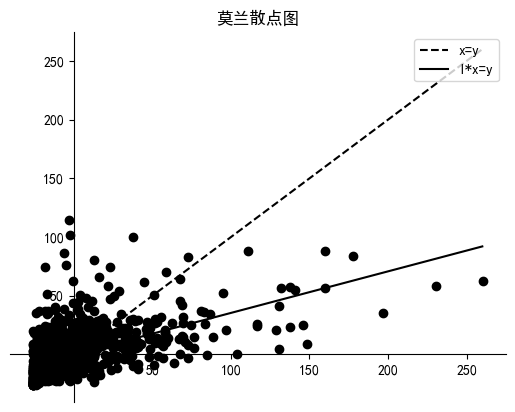

In [35]:

h3_node = df
spaceMatrix = pd.DataFrame({},index=h3_node.H3,columns=h3_node.H3)
for province1 in spaceMatrix.index:
    for province2 in spaceMatrix.columns:
        if not np.isnan(spaceMatrix.loc[province1,province2]):
            continue
        #两地距离
        try:
            distance = h3.point_dist(h3.h3_to_geo(province1),h3.h3_to_geo(province2),'km')
            spaceMatrix.loc[province1,province2] = distance
            spaceMatrix.loc[province2,province1] = distance
        except:
            spaceMatrix.loc[province1,province2] = np.nan
            spaceMatrix.loc[province2,province1] = np.nan
            continue
        #地点相同，距离取无穷大，不然后面的倒数会报错
        if province1==province2:
            spaceMatrix.loc[province1,province2] = 10e9
spaceMatrix = spaceMatrix**-3

from MoranI import moranI
date_stre = h3_node.loc[:,'Degree'].to_frame().fillna(0)
result = moranI(spaceMatrix,date_stre)
print('all:\n','moran:',result['I']['value'],'\n','test:',result['ZI_N']['value'])

In [78]:
centre_lng = (df_station['gcj_lng'].max()+df_station['gcj_lng'].min())/2+0.1
centre_lat = (df_station['gcj_lat'].mean()+df_station['gcj_lat'].min())/2+0.14
attr_anno = 'Map tiles by &copy; <a href="https://carto.com/attributions">CARTO</a>, under <a href="http://creativecommons.org/licenses/by/3.0">CC BY 3.0</a>. Data by &copy; <a href="https://www.openstreetmap.org/copyright">OpenStreetMap</a>, under <a href="https://creativecommons.org/licenses/by-sa/3.0/">CC-BY-SA</a>.'
map_tile = 'https://{s}.basemaps.cartocdn.com/light_nolabels/{z}/{x}/{y}{r}.png'

In [ ]:

city_map = folium.Map(
    location = [centre_lat, centre_lng],
    zoom_start = 11,
    max_zoom = 14,
    min_zoom = 11,
    no_touch = True,
    zoom_control = False,
    control_scale = True,
    prefer_canvas = True,
    attr = attr_anno,
    tiles = map_tile,
)


#站点
station_map = folium.map.FeatureGroup()
for row_index, row_data in df.iterrows():
    station_map.add_child(
        folium.Circle(
            row_data['H3_Center'],
            radius = 80,
            color = row_data['Community_Color'],
            fill = True,
            fill_color = row_data['Community_Color']+'255',
            opacity = 1,
        )
    )
    
location_map = city_map.add_child(station_map)
location_map
# res_name = 'RES=%s' % res
# map_name = 'basemap(res=%s).html' % res
# map_path = os.path.join(work_path,'Results','Lianyungang',res_name,map_name)
# location_map.save(map_path)

In [23]:
graph_structure  = pd.DataFrame({
    'date': [day_format],
    'node': [G.number_of_nodes()],
    'node_connection': [len(daily_hexgon)],
    'edges': [G.number_of_edges()],
    'c': [nx.average_clustering(G)]
})
all_graph = pd.concat([all_graph,graph_structure]).reset_index(drop=True)

Strength（带权重出入度）评价

In [68]:
strength = pd.DataFrame(nx.degree(G,weight='weight'))
strength.columns = ['hex_id','strength_values']
strength['date'] = day_format
strength = strength[strength['strength_values']>0]

strength_data = strength.strength_values.values
strength_fit = powerlaw.Fit(strength_data,verbose=False,)
strength_alpha = strength_fit.power_law.alpha
strength_s, strength_p = kstest(strength_data, 'powerlaw',args=[strength_alpha])
strength_xmin = strength_fit.xmin

strength_output = pd.DataFrame({
    'date': [day_format],
    'alpha': [strength_alpha],
    'ks-s': [strength_s],
    'ks-p': [strength_p],
    'xmin': [strength_xmin]
})

all_strength = pd.concat([all_strength,strength]).reset_index(drop=True)
all_strength_powerlaw = pd.concat([all_strength_powerlaw,strength_output]).reset_index(drop=True)

In [248]:
in_degree = pd.DataFrame(G.degree(weight='weights'))
in_degree.columns = ['id','degree']

in_degree = in_degree[(in_degree['degree']>25)&(in_degree['degree']<=102)]
in_count = in_degree['degree'].value_counts().to_frame().reset_index(drop=False).sort_values('index')
xdata = in_count['index'].values
ydata = in_count['degree'].values


Calculating best minimal value for power law fit
alpha= 2.849155433847823
[1. 1. 1. 1.]


c:\Users\Tlab\AppData\Local\Programs\Python\Python39\lib\site-packages\scipy\optimize\_minpack_py.py:833: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',


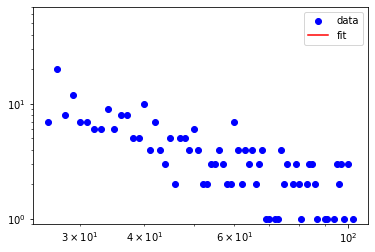

In [249]:

fit = powerlaw.Fit(in_degree['degree'].values)
print("alpha=",fit.alpha)

def func(x,alpha,beta,c,A):
    pl = np.power((x+c),(-1*alpha))
    ex = np.exp(-1*x/beta)
    return A*pl*ex

popt, pcov = curve_fit(func, xdata, ydata,maxfev = 510000)
print(popt)
plt.scatter(xdata, ydata, color='b', label='data')
plt.plot(xdata, func(xdata, *popt), 'r-', label='fit')
plt.xscale('log')
plt.yscale('log')
plt.ylim((0.9,70))
plt.legend()
plt.show()


In [239]:
from kneed import KneeLocator
kn = KneeLocator(xdata,ydata,S=30,curve='convex',direction='decreasing',online=True)
kn.all_elbows

{7, 12, 26, 102}

In [247]:
print(xdata,'\n',ydata)
print(func(xdata, *popt))
print(kstest(ydata,func(xdata, *popt)))
print(kstest(in_degree['degree'].values,'powerlaw',args=[fit.alpha]))

[ 12  13  14  15  16  17  18  19  20  21  22  23  24  25  26  27  28  29
  30  31  32  33  34  35  36  37  38  39  40  41  42  43  44  45  46  47
  48  49  50  51  52  53  54  55  56  57  58  59  60  61  62  63  64  65
  66  67  68  69  70  72  73  74  75  76  78  79  80  81  83  84  85  86
  87  90  91  94  95  96  97  98 100 102] 
 [13 19 28 24 23 18 19 14 12 16 12 13 13 11  7 20  8 12  7  7  6  6  9  6
  8  8  5  5 10  4  7  4  3  5  2  5  5  4  6  4  2  2  3  3  4  3  2  2
  7  4  2  4  3  4  2  3  4  1  1  1  1  4  2  3  2  3  2  1  2  3  3  2
  1  1  1  1  3  2  3  1  3  1]
[22.78253303 21.54265403 20.38837162 19.31256383 18.30879913 17.3712603
 16.49467764 15.67427037 14.90569496 14.1849996  13.50858399 12.87316372
 12.27573871 11.71356513 11.18413049 10.68513142 10.21445378  9.77015499
  9.35044812  8.95368767  8.57835681  8.22305592  7.88649222  7.56747047
  7.26488459  6.97771006  6.70499706  6.44586422  6.19949304  5.96512271
  5.74204552  5.52960259  5.32718003  5.13420544 

In [104]:
a = strength['strength_values'].value_counts().to_frame().reset_index(drop=False).sort_values('index')
a.to_csv('data.csv',index=None)

<AxesSubplot:>

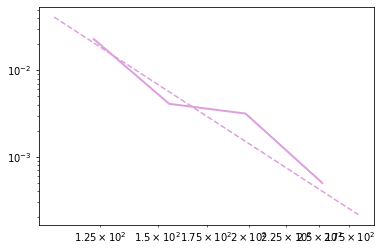

In [32]:
fig2 = fit.plot_pdf(color='Plum',linewidth = 2)
fit.power_law.plot_pdf(color='Plum',linestyle='--',ax=fig2)
# strength_fit.plot_pdf(color='Olive',linewidth = 2,ax=fig2)
# strength_fit.power_law.plot_pdf(color='Olive',linestyle='--',ax=fig2)

In [28]:
draw_strength = pd.merge(
    station_hex[station_hex['h3_address'].isin(daily_hexgon['hex_id'])],
    strength,
    how='left',
    left_on='h3_address',
    right_on='hex_id')
strength_vmin = draw_strength["strength_values"].min()
strength_vmax = draw_strength["strength_values"].max()
strength_colormap = linear.YlOrBr_09.scale(strength_vmin,strength_vmax)

strength_map = folium.Map(
    location = [centre_lat, centre_lng],
    zoom_start = 11,
    max_zoom = 14,
    min_zoom = 9,
    no_touch = True,
    zoom_control = False,
    control_scale = True,
    prefer_canvas = True,
    #tiles = 'http://map.geoq.cn/ArcGIS/rest/services/ChinaOnlineStreetGray/MapServer/tile/{z}/{y}/{x}',
    tiles = 'https://map.geoq.cn/arcgis/rest/services/ChinaOnlineStreetPurplishBlue/MapServer/tile/{z}/{y}/{x}',
    attr = 'connectivity'
)


strength_hex = folium.map.FeatureGroup()
for row_index, row_data in draw_strength.iterrows():
    strength_hex.add_child(
        folium.Polygon(
            row_data['Polygon'],
            color = strength_colormap(row_data['strength_values']),
            fill_color = strength_colormap(row_data['strength_values']),
            fill_opacity = 0.25+(row_data['strength_values']-strength_vmin)/(strength_vmax-strength_vmin),
            fill = True,
            weight = 1,
        )
    )
strength_map = strength_map.add_child(strength_hex)
strength_colormap.caption = "Strength"
strength_colormap.add_to(strength_map)

strength_map_name = 'strength_%s.html' % day
strength_map_path = os.path.join(work_path,'Results','Lianyungang',res_name,strength_map_name)
strength_map.save(strength_map_path)
strength_map

PageRank评价

In [29]:
PageRank = pd.DataFrame([nx.pagerank(G,weight='weight')]).T.reset_index(drop=False)
PageRank.columns = ['hex_id','page_values']
PageRank['date'] = day_format
PageRank = PageRank[PageRank['hex_id'].isin(daily_hexgon['hex_id'])]
PageRank['page_values'] = PageRank['page_values'].apply(lambda x: x/PageRank['page_values'].sum())

In [30]:
draw_PageRank = pd.merge(
    station_hex[station_hex['h3_address'].isin(daily_hexgon['hex_id'])],
    PageRank,
    how='left',
    left_on='h3_address',
    right_on='hex_id')
PageRank_vmin = draw_PageRank["page_values"].min()
PageRank_vmax = draw_PageRank["page_values"].max()
PageRank_colormap = linear.YlOrRd_09.scale(PageRank_vmin,PageRank_vmax)

PageRank_map = folium.Map(
    location = [centre_lat, centre_lng],
    zoom_start = 11,
    max_zoom = 14,
    min_zoom = 9,
    no_touch = True,
    zoom_control = False,
    control_scale = True,
    prefer_canvas = True,
    #tiles = 'http://map.geoq.cn/ArcGIS/rest/services/ChinaOnlineStreetGray/MapServer/tile/{z}/{y}/{x}',
    tiles = 'https://map.geoq.cn/arcgis/rest/services/ChinaOnlineStreetPurplishBlue/MapServer/tile/{z}/{y}/{x}',
    attr = 'connectivity'
)


PageRank_hex = folium.map.FeatureGroup()
for row_index, row_data in draw_PageRank.iterrows():
    PageRank_hex.add_child(
        folium.Polygon(
            row_data['Polygon'],
            color = PageRank_colormap(row_data['page_values']),
            fill_color = PageRank_colormap(row_data['page_values']),
            fill_opacity = 0.4+(row_data['page_values']-PageRank_vmin)/(PageRank_vmax-PageRank_vmin),
            fill = True,
            weight = 1,
        )
    )
PageRank_map = PageRank_map.add_child(PageRank_hex)
PageRank_colormap.caption = "PageRank"
PageRank_colormap.add_to(PageRank_map)

PageRank_map_name = 'PageRank_%s.html' % day
PageRank_map_path = os.path.join(work_path,'Results','Lianyungang',res_name,PageRank_map_name)
PageRank_map.save(PageRank_map_path)

In [31]:
PageRank

,hex_id,page_values,date
11,883084a50bfffff,0.011377,2022-01-13
12,8830843369fffff,0.002821,2022-01-13
13,883084a805fffff,0.000831,2022-01-13
14,883084aae3fffff,0.000664,2022-01-13
15,883084a809fffff,0.000648,2022-01-13
...,...,...,...
602,883084a303fffff,0.000661,2022-01-13
604,88308404ddfffff,0.001455,2022-01-13
605,883084a917fffff,0.000734,2022-01-13
608,883084322bfffff,0.000672,2022-01-13
